# Computer Vision (Image operators and filters)

By the end of this lab, you will get hands on experience working with:

*   Image Handling
*   Image Manipulation
*   Histogram and Histogram Equalization
*   Basic filtering techniques

<!-- ### **Remember this is a graded exercise.** -->

**Reminder**:

*   For every plot, make sure you provide appropriate titles, axis labels, legends, wherever applicable.
*   Add sufficient comments and explanations wherever necessary.

---


In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from skimage import data, exposure, filters, io, morphology

# Channels and color spaces

### **Exercise: Image Creation and Color Manipulation**

*   Create a 100 x 100 image for each of the below visualization

![image.png](attachment:image.png)

*   Visualize the created images in a 1 x 3 subplot using matplotlib.


In [ ]:
img1 = np.zeros((100, 100), dtype=np.uint8)
img2 = np.zeros((100, 100), dtype=np.uint8)
img3 = np.zeros((100, 100), dtype=np.uint8)

In [ ]:
img1[:, 50:] = 255
img2[50:, :] = 255
img3[:50, :50] = 255

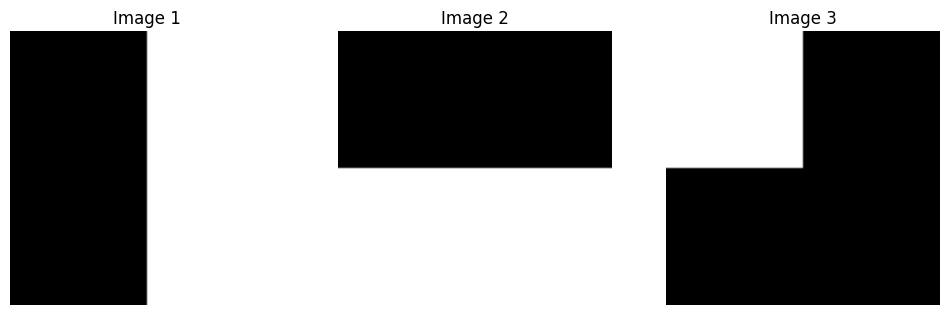

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img1, cmap='gray')
axes[0].set_title('Image 1')
axes[0].axis('off')

axes[1].imshow(img2, cmap='gray')
axes[1].set_title('Image 2')
axes[1].axis('off')

axes[2].imshow(img3, cmap='gray')
axes[2].set_title('Image 3')
axes[2].axis('off')

plt.show()

*   Use the above three images to create the following image

![image-2.png](attachment:image-2.png)
*Hint: Remember channels and color spaces*

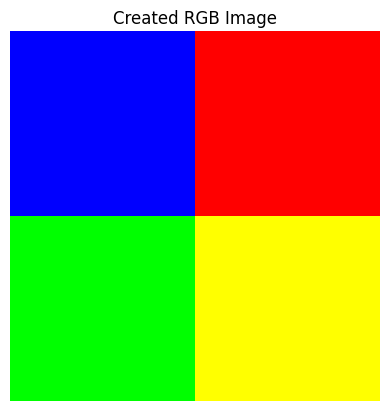

In [ ]:
created_image = np.zeros((100, 100, 3), dtype=np.uint8)
created_image[:, :, 0] = img1
created_image[:, :, 1] = img2
created_image[:, :, 2] = img3

plt.imshow(created_image)
plt.title('Created RGB Image')
plt.axis('off')
plt.show()


### **Exercise: Color Manipulation**

*   Read the image 'sillas.jpg' from the images folder

![image.png](attachment:image.png)

*   Extract individual channels and plot them using matplotlib subplot.



In [ ]:
from google.colab import files
uploaded = files.upload()

Saving sillas.jpg to sillas (1).jpg


In [ ]:
filename = list(uploaded.keys())[0]
sillas = io.imread(filename)

In [ ]:
red_channel = sillas[:, :, 0]
green_channel = sillas[:, :, 1]
blue_channel = sillas[:, :, 2]

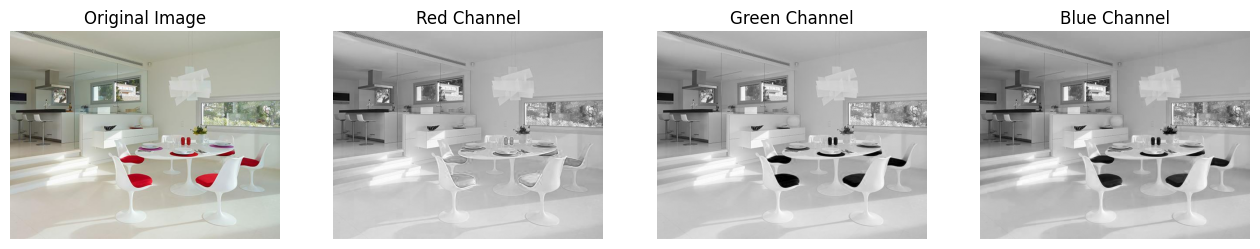

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(sillas)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(red_channel, cmap='gray')
axes[1].set_title('Red Channel')
axes[1].axis('off')

axes[2].imshow(green_channel, cmap='gray')
axes[2].set_title('Green Channel')
axes[2].axis('off')

axes[3].imshow(blue_channel, cmap='gray')
axes[3].set_title('Blue Channel')
axes[3].axis('off')

plt.show()

*   The color **red** looks too bright for the eyes. Isn't it?? Lets change the color and see how it appears.
    *    Create a new image where everything that is **'red' is changed to 'blue'**.
*   Visualize the original image and the created image using matplotlib subplot.

In [ ]:
sillas_blue = sillas.copy()

In [ ]:
red_mask = ((sillas[:, :, 0] > 150) &
            (sillas[:, :, 1] < 120) &
            (sillas[:, :, 2] < 120))

sillas_blue[red_mask] = [0, 0, 255]

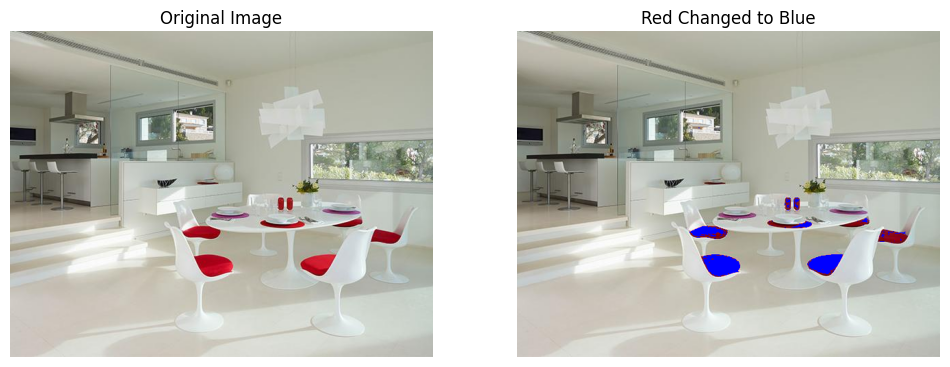

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(sillas)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(sillas_blue)
axes[1].set_title('Red Changed to Blue')
axes[1].axis('off')

plt.show()

# Image Manipulation

### **Exercise: Image Operators**

*   You can find images 'model.png' and 'coat.png' in the images folder (First two images of the below visualization). Your task is to create an image from the given two images such a way that the model is wearing the coat (Third image in the visualization).
*   You can also find different textures in the images folder. Your task is to change the coat texture to any one of the given textures.
*   Visualize the images similar to the given visualization.

*Hint: Think masks!!!*

![image.png](attachment:image.png)

In [ ]:
model = io.imread('../images/model.png')
coat = io.imread('../images/coat.png')
texture = io.imread('../images/texture3.jpg')